# Aplicação de um SIN para controle de uma máquina de lavar roupas.

O problema é desenvolver e implementar um SIN para o ajuste do ciclo (tempo) de funciona-
mento em uma máquina de lavar roupas.
Nesse exemplo, o controle considerará o grau de **sujeira**, a quantidade de **manchas** e a quantidade de **roupas**.


In [96]:
%%html
<style>
  table > caption,
  table > tbody > tr > th {
    font-weight: bold;
  }
</style>


In [97]:
import numpy as np
import skfuzzy as fuzzy
from babel.numbers import format_currency as currency
from babel.numbers import format_decimal as decimal
from IPython.display import HTML, display
from skfuzzy import control as ctrl

## Modelagem do problema

A modelagem nebulosa do problema real compreende:

1.  definir o contexto e a questão a ser tratada. I.e., definir o problema que se quer resolver, a pergunta que se quer responder ou a decisão a ser tomada. Ainda, definir qual o contexto da questão, ou seja, definir os atores e sob quais circunstâncias, aspectos e negócio a questão está sendo percebida;

2.  definir qual a variável linguística de saída que será o resultado, resposta ou decisão da questão a ser tratada;

3.  definir os termos linguísticos (conjuntos nebulosos) da variável de saída. I.e., os possíveis valores que a variável de saída pode assumir;

4.  definir a representação dos conjuntos nebulosos da variável de saída. I.e., em geral, definir se a representação será por função de pertinência ou explícita (p. ex., listando os elementos do conjunto nebuloso em uma tabela);

5.  definir as variáveis linguísticas de entrada;

6.  definir os termos linguísticos (conjuntos nebulosos) de cada variável de entrada. I.e., os possíveis valores que as variáveis de entrada podem assumir;

7.  definir a representação dos conjuntos nebulosos das variáveis de entrada. I.e., em geral, definir se a representação será por função de pertinência ou explícita (p. ex., listando os elementos do conjunto nebuloso em uma tabela);

8.  definir as regras de inferência;

9.  definir o método de inferência que, na maioria das vezes, poderá ser Mandani ou Larsen. Mas, podem ser usado outros métodos, dependendo do problema em questão;

10. definir o método de defuzzificação.


## Definição do problema


### Contexto

- **Objetivo:** Aplicação de um SIN para o controle de uma máquina de lavar roupas.
- **Pergunta:** Qual é o tempo do ciclo de lavagem a ser feito?
- **Atores:** Usuário da máquina de lavar roupas, e o sistema da máquina.
- **Circunstâncias:** O usuário preencherá as informações, e a máquina executará o ciclo apropriado.
- **Aspectos:** Espera-se que uma quantidade maior de roupas, e que um nível maior de sujeira e de manchas levem a mais longos ciclos.


### Saída

#### Duração

Tempo de **duração** do ciclo de lavagem.

- Dado em minutos (min).
- Intervalo aproximado de 0 min a 60 min.
- Traduz a quantidade de roupas e a necessidade de limpeza.

Termos linguísticos:

- Muito curto (`MC`): Até 10 minutos.
- Curto (`C`): Maior que 10 minutos.
- Médio (`M`): Próximo a 25 minutos.
- Longo (`L`): Próximo a 40 minutos.
- Muito longo (`ML`): Maior que 40 minutos.

Representação:

- Funções de pertinência:
  - lineares para os termos `MC` e `ML`;
  - triangulares para os termos `C`, `M` e `L`.


/home/gabriel/dev/fuzzy_systems/a1s2/.venv/lib64/python3.14/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


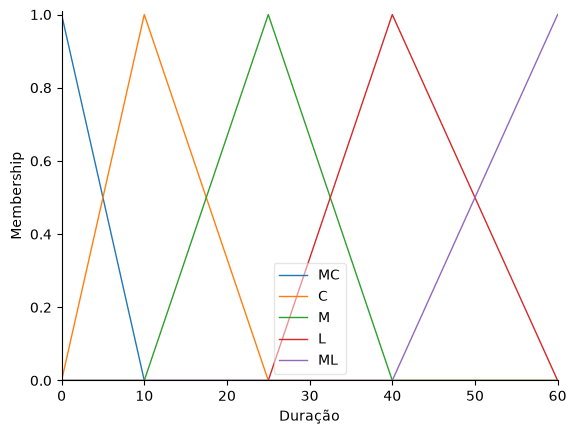

In [98]:
# Define o universo de valores.
duration_universe = np.arange(0, 61, 1)

# Define a variável.
duration_variable = ctrl.Consequent(duration_universe, "Duração")

# Define a função de pertinência.
duration_variable["MC"] = fuzzy.trimf(duration_variable.universe, [0, 0, 10])
duration_variable["C"] = fuzzy.trimf(duration_variable.universe, [0, 10, 25])
duration_variable["M"] = fuzzy.trimf(duration_variable.universe, [10, 25, 40])
duration_variable["L"] = fuzzy.trimf(duration_variable.universe, [25, 40, 60])
duration_variable["ML"] = fuzzy.trimf(duration_variable.universe, [40, 60, 60])

duration_variable.view()

# Checagem de cobertura.
duration_coverage = np.maximum.reduce(
    [
        duration_variable["MC"].mf,
        duration_variable["C"].mf,
        duration_variable["M"].mf,
        duration_variable["L"].mf,
        duration_variable["ML"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {duration_universe[duration_coverage == 0]}"))


### Entrada


#### Sujeira

Grau de **sujeira** das roupas.

- Dado em porcentagem.
- Intervalo de 0 a 100 pontos percentuais.

Termos linguísticos:

- Pequeno grau de sujeira (`PS`): até 50%.
- Médio grau de sujeira (`MS`): próximo a 50%.
- Grande grau de sujeira (`GS`): maior que 50%.

Representação:

- Funções de pertinência:
  - lineares para os termos `PS` e `GS`;
  - triangular para o termo `MS`.


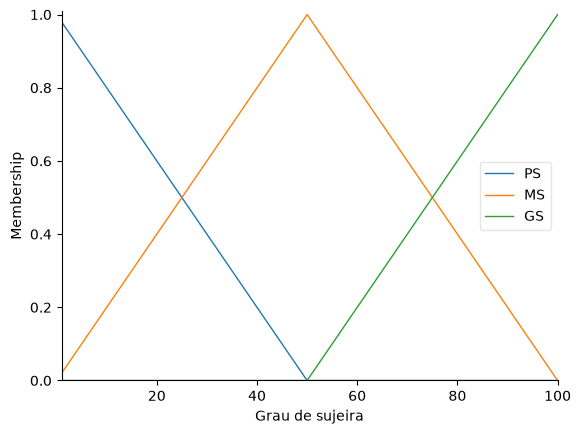

In [99]:
# Define o universo de valores.
dirtiness_universe = np.arange(1, 101, 1)

# Define a variável.
dirtiness_variable = ctrl.Antecedent(dirtiness_universe, "Grau de sujeira")

# Define as funções de pertinência.
dirtiness_variable["PS"] = fuzzy.trimf(dirtiness_universe, [0, 0, 50])
dirtiness_variable["MS"] = fuzzy.trimf(dirtiness_universe, [0, 50, 100])
dirtiness_variable["GS"] = fuzzy.trimf(dirtiness_universe, [50, 100, 100])

dirtiness_variable.view()

# Checagem de cobertura.
dirtiness_coverage = np.maximum.reduce(
    [
        dirtiness_variable["PS"].mf,
        dirtiness_variable["MS"].mf,
        dirtiness_variable["GS"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {dirtiness_universe[dirtiness_coverage == 0]}"))


#### Manchas

Grau de **manchas** nas roupas.

- Dado em porcentagem.
- Intervalo de 0 a 100 pontos percentuais.

Termos linguísticos:

- Pequena quantidade de manchas (`PM`): até 50%.
- Média quantidade de manchas (`MM`): próximo a 50%.
- Grande quantidade de manchas (`GM`): maior que 50%.

Representação:

- Funções de pertinência:
  - lineares para os termos `PM` e `GM`;
  - triangular para o termo `MM`.


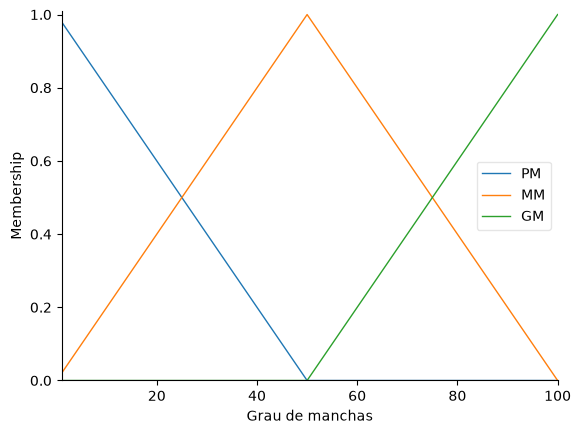

In [100]:
# Define o universo de valores.
stains_universe = np.arange(1, 101, 1)

# Define a variável.
stains_variable = ctrl.Antecedent(stains_universe, "Grau de manchas")

# Define as funções de pertinência.
stains_variable["PM"] = fuzzy.trimf(stains_universe, [0, 0, 50])
stains_variable["MM"] = fuzzy.trimf(stains_universe, [0, 50, 100])
stains_variable["GM"] = fuzzy.trimf(stains_universe, [50, 100, 100])

stains_variable.view()

# Checagem de cobertura.
stains_coverage = np.maximum.reduce(
    [
        stains_variable["PM"].mf,
        stains_variable["MM"].mf,
        stains_variable["GM"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {stains_universe[stains_coverage == 0]}"))


#### Quantidade

Quantidade de **roupas** para lavar.

- Dado em quilogramas (Kg).
- Intervalo de 1 Kg a 12 Kg.

Termos linguísticos:

- Pouca quantidade (`PQ`): de 1 Kg até 4 Kg.
- Média quantidade (`MQ`): de 4 Kg até 7 Kg.
- Grande quantidade (`GQ`): de 7 Kg até 10 Kg.
- Muito grande quantidade (`MGQ`): de 10 Kg até 12 Kg.

Representação:

- Funções de pertinência:
  - lineares para os termos `PQ` e `MGQ`;
  - triangulares para os termos `MQ` e `GQ`.


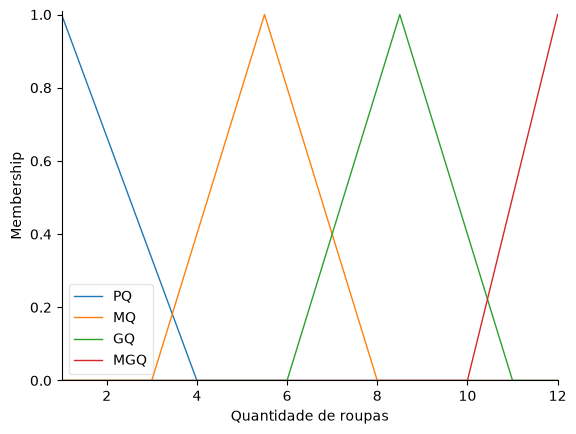

In [101]:
# Define o universo de valores.
quantity_universe = np.arange(1, 12.5, 0.5)

# Define a variável.
quantity_variable = ctrl.Antecedent(quantity_universe, "Quantidade de roupas")

# Define as funções de pertinência.
quantity_variable["PQ"] = fuzzy.trimf(quantity_universe, [1, 1, 4])
quantity_variable["MQ"] = fuzzy.trimf(quantity_universe, [3, 5.5, 8])
quantity_variable["GQ"] = fuzzy.trimf(quantity_universe, [6, 8.5, 11])
quantity_variable["MGQ"] = fuzzy.trimf(quantity_universe, [10, 12, 12])

quantity_variable.view()

# Checagem de cobertura.
quantity_coverage = np.maximum.reduce(
    [
        quantity_variable["PQ"].mf,
        quantity_variable["MQ"].mf,
        quantity_variable["GQ"].mf,
        quantity_variable["MGQ"].mf,
    ]
)
display(HTML(f"Valores sem cobertura: {quantity_universe[quantity_coverage == 0]}"))

## Criação de regras de inferência


### Matrizes associativas fuzzy

#### Quantidade: Pouca (`PQ`)

**Sujeira / Manchas**

|        |  PM |  MM |  GM |
| ------ | --: | --: | --: |
| **PS** |  MC |  MC |   C |
| **MS** |  MC |   C |   C |
| **GS** |   C |   C |   M |

#### Quantidade: Média (`MQ`)

**Sujeira / Manchas**

|        |  PM |  MM |  GM |
| ------ | --: | --: | --: |
| **PS** |   C |   C |   M |
| **MS** |   C |   M |   M |
| **GS** |   M |   M |   L |

#### Quantidade: Grande (`GQ`)

**Sujeira / Manchas**

|        |  PM |  MM |  GM |
| ------ | --: | --: | --: |
| **PS** |   M |   M |   L |
| **MS** |   M |   L |   L |
| **GS** |   L |   L |  ML |

#### Quantidade: Muito grande (`MGQ`)

**Sujeira / Manchas**

|        |  PM |  MM |  GM |
| ------ | --: | --: | --: |
| **PS** |   L |   L |  ML |
| **MS** |   L |  ML |  ML |
| **GS** |  ML |  ML |  ML |


### Definição das regras


In [102]:
# Quantidade: Pouca (PQ)

r1 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["PM"] & quantity_variable["PQ"],
    duration_variable["MC"],
)
r2 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["MM"] & quantity_variable["PQ"],
    duration_variable["MC"],
)
r3 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["GM"] & quantity_variable["PQ"],
    duration_variable["C"],
)
r4 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["PM"] & quantity_variable["PQ"],
    duration_variable["MC"],
)
r5 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["MM"] & quantity_variable["PQ"],
    duration_variable["C"],
)
r6 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["GM"] & quantity_variable["PQ"],
    duration_variable["C"],
)
r7 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["PM"] & quantity_variable["PQ"],
    duration_variable["C"],
)
r8 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["MM"] & quantity_variable["PQ"],
    duration_variable["C"],
)
r9 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["GM"] & quantity_variable["PQ"],
    duration_variable["M"],
)

# Quantidade: Média (MQ)

r10 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["PM"] & quantity_variable["MQ"],
    duration_variable["C"],
)
r11 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["MM"] & quantity_variable["MQ"],
    duration_variable["C"],
)
r12 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["GM"] & quantity_variable["MQ"],
    duration_variable["M"],
)
r13 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["PM"] & quantity_variable["MQ"],
    duration_variable["C"],
)
r14 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["MM"] & quantity_variable["MQ"],
    duration_variable["M"],
)
r15 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["GM"] & quantity_variable["MQ"],
    duration_variable["M"],
)
r16 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["PM"] & quantity_variable["MQ"],
    duration_variable["M"],
)
r17 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["MM"] & quantity_variable["MQ"],
    duration_variable["M"],
)
r18 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["GM"] & quantity_variable["MQ"],
    duration_variable["L"],
)

# Quantidade: Grande (GQ)

r19 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["PM"] & quantity_variable["GQ"],
    duration_variable["M"],
)
r20 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["MM"] & quantity_variable["GQ"],
    duration_variable["M"],
)
r21 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["GM"] & quantity_variable["GQ"],
    duration_variable["L"],
)
r22 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["PM"] & quantity_variable["GQ"],
    duration_variable["M"],
)
r23 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["MM"] & quantity_variable["GQ"],
    duration_variable["L"],
)
r24 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["GM"] & quantity_variable["GQ"],
    duration_variable["L"],
)
r25 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["PM"] & quantity_variable["GQ"],
    duration_variable["L"],
)
r26 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["MM"] & quantity_variable["GQ"],
    duration_variable["L"],
)
r27 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["GM"] & quantity_variable["GQ"],
    duration_variable["ML"],
)

# Quantidade: Muito grande (MGQ)

r28 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["PM"] & quantity_variable["MGQ"],
    duration_variable["L"],
)
r29 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["MM"] & quantity_variable["MGQ"],
    duration_variable["L"],
)
r30 = ctrl.Rule(
    dirtiness_variable["PS"] & stains_variable["GM"] & quantity_variable["MGQ"],
    duration_variable["ML"],
)
r31 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["PM"] & quantity_variable["MGQ"],
    duration_variable["L"],
)
r32 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["MM"] & quantity_variable["MGQ"],
    duration_variable["ML"],
)
r33 = ctrl.Rule(
    dirtiness_variable["MS"] & stains_variable["GM"] & quantity_variable["MGQ"],
    duration_variable["ML"],
)
r34 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["PM"] & quantity_variable["MGQ"],
    duration_variable["ML"],
)
r35 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["MM"] & quantity_variable["MGQ"],
    duration_variable["ML"],
)
r36 = ctrl.Rule(
    dirtiness_variable["GS"] & stains_variable["GM"] & quantity_variable["MGQ"],
    duration_variable["ML"],
)

# Compilação

rules = [
    r1,
    r2,
    r3,
    r4,
    r5,
    r6,
    r7,
    r8,
    r9,
    r10,
    r11,
    r12,
    r13,
    r14,
    r15,
    r16,
    r17,
    r18,
    r19,
    r20,
    r21,
    r22,
    r23,
    r24,
    r25,
    r26,
    r27,
    r28,
    r29,
    r30,
    r31,
    r32,
    r33,
    r34,
    r35,
    r36,
]


## Simulação

### Controle


In [103]:
### Método de controle

price_ctrl = ctrl.ControlSystem(rules)
price_simulation = ctrl.ControlSystemSimulation(price_ctrl)


def predict_price(age: int, glycemia: float, body_fat: float):
    price_simulation.input["Idade"] = age
    price_simulation.input["Glicemia"] = glycemia
    price_simulation.input["Gordura"] = body_fat
    price_simulation.compute()
    return price_simulation.output["Preço"]


def simulate_and_display(
    age: int,
    glycemia: float,
    body_fat: float,
    plot_input: bool = False,
    plot_output=False,
):
    prediction = predict_price(age=age, glycemia=glycemia, body_fat=body_fat)
    display(
        HTML(
            f"""<table><caption>Simulação de preço de seguro de saúde.</caption>
                    <thead>
                        <tr><th>Idade</th><th>Glicemia (mg/dL)</th><th>Gordura (%)</th><th>Preço (R$)</th></tr>
                    </thead>
                    <tbody>
                        <tr><td>{age}</td><td>{decimal(glycemia, locale="pt_BR")}</td><td>{decimal(body_fat, locale="pt_BR")}</td><td>{currency(prediction, "BRL", locale="pt_BR")}</td>
                    </tbody>
                </table>"""
        )
    )
    if plot_input:
        dirtiness_variable.view(sim=price_simulation)
        glycemia_variable.view(sim=price_simulation)
        quantity_variable.view(sim=price_simulation)
    if plot_output:
        price_variable.view(sim=price_simulation)


def simulate_and_display_many(data):
    rows = []

    for age, glycemia, body_fat in data:
        prediction = predict_price(age=age, glycemia=glycemia, body_fat=body_fat)

        rows.append(
            f"""
            <tr>
                <td>{age}</td>
                <td>{decimal(glycemia, locale="pt_BR")}</td>
                <td>{decimal(body_fat, locale="pt_BR")}</td>
                <td>{currency(prediction, "BRL", locale="pt_BR")}</td>
            </tr>
            """
        )

    display(
        HTML(
            f"""
            <table>
                <caption>Simulação de preço de seguro de saúde.</caption>
                <thead>
                    <tr>
                        <th>Idade</th>
                        <th>Glicemia (mg/dL)</th>
                        <th>Gordura (%)</th>
                        <th>Preço (R$)</th>
                    </tr>
                </thead>
                <tbody>
                    {"".join(rows)}
                </tbody>
            </table>
            """
        )
    )

In [104]:
simulate_and_display(age=28, glycemia=85, body_fat=30)


ValueError: Unexpected input: Idade

### Método de inferência

Foi decidido utilizar o método de Mamdani, que é o padrão da biblioteca.


In [ ]:
simulate_and_display(age=28, glycemia=85, body_fat=30, plot_input=True)


### Defuzzificação

Foi decidido utilizar o método de Centroide, que é o padrão da biblioteca.


In [ ]:
simulate_and_display(age=28, glycemia=85, body_fat=30, plot_output=True)


## Exemplos


In [ ]:
simulate_and_display_many(
    data=[
        (16, 70, 20),
        (28, 85, 30),
        (25, 85, 12),
        (35, 105, 22),
        (55, 130, 28),
        (75, 150, 35),
    ]
)
